1. Chargement des donnees Transports (Filtre Paris 75)...
2. Chargement et calcul de la meteo REGIONALE (Ile-de-France)...
3. Fusion et Creation des variables...

4. Statistiques du jeu de donnees...
--------------------------------------------------
Nombre total de jours analyses : 184
Trafic moyen journalier        : 2,233,494 voyageurs
Trafic maximum (pic)           : 3,743,515 voyageurs
Trafic minimum (creux)         : 171,281 voyageurs
Nombre de jours de greve       : 27 jours
--------------------------------------------------

5. Preparation et Entrainement de l'IA...

RESULTATS DU MODELE CORRIGE :
- Marge d'erreur absolue : 158312 voyageurs / jour
- Marge d'erreur relative: 9.9%
- Score R2               : 0.93 / 1.00


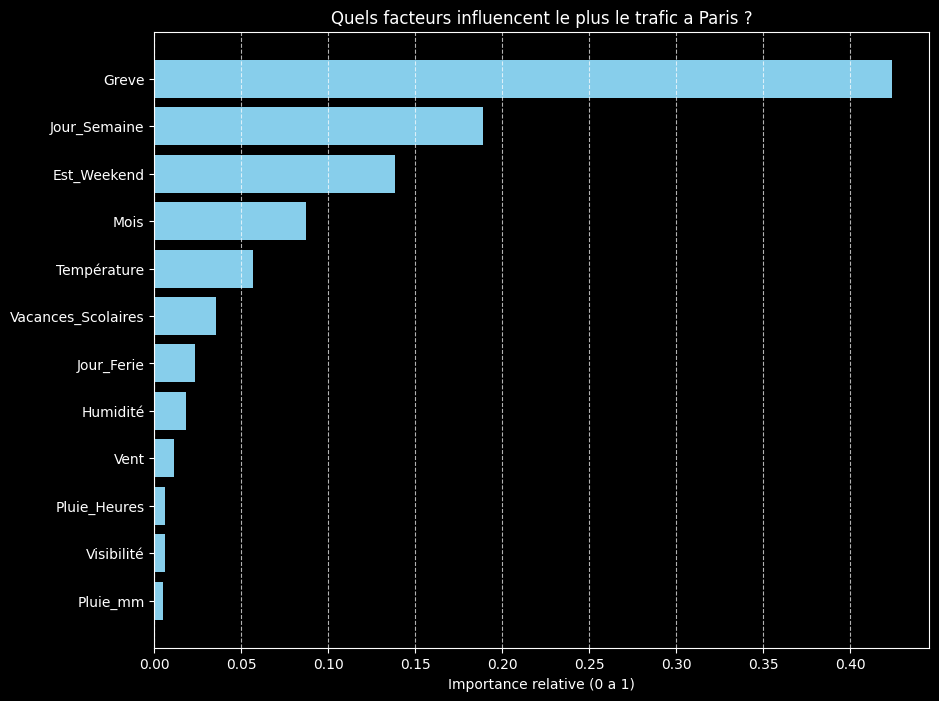


SIMULATEUR D'AFFLUENCE RATP (PARIS 75)
Lundi de Novembre (Normal)             : 3,287,987 voyageurs
Lundi de Novembre (Ferie - ex: 11 nov) : 2,023,637 voyageurs
Lundi de Novembre (Vacances Scolaires) : 3,203,159 voyageurs
Lundi de Novembre (Greve)              : 865,121 voyageurs
--------------------------------------------------
IMPACTS CALCULES PAR L'IA :
  - Un jour ferie fait chuter le trafic de 38.5%
  - Les vacances font chuter le trafic de 2.6%
  - La greve fait chuter le trafic de 73.7%


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt

print("1. Chargement des donnees Transports (Filtre Paris 75)...")
df_transports = pd.read_csv('Travel_titles_with_departments.csv')
df_transports = df_transports[df_transports['DEPARTEMENT'] == 75].copy()
df_transports['DATE'] = pd.to_datetime(df_transports['DATE'])
df_transports = df_transports.groupby('DATE', as_index=False)['NB_VALID'].sum()

print("2. Chargement et calcul de la meteo REGIONALE (Ile-de-France)...")
departements = [75, 77, 78, 91, 92, 93, 94, 95]
liste_df = []

for dep in departements:
    nom_fichier = f'H_{dep}_2010-2019.csv.gz'
    try:
        df_temp = pd.read_csv(nom_fichier, compression='gzip', sep=';', low_memory=False)
        liste_df.append(df_temp)
    except FileNotFoundError:
        print(f"   [!] Fichier manquant ignore : {nom_fichier}")

# Fusion et nettoyage des dates météo
df_meteo_raw = pd.concat(liste_df, ignore_index=True)
df_meteo_raw['DATE_FULL'] = pd.to_datetime(df_meteo_raw['AAAAMMJJHH'], format='%Y%m%d%H')
df_meteo_filtre = df_meteo_raw[(df_meteo_raw['DATE_FULL'] >= '2019-07-01') & (df_meteo_raw['DATE_FULL'] <= '2019-12-31')].copy()
df_meteo_filtre['JOUR'] = df_meteo_filtre['DATE_FULL'].dt.normalize()

# Calcul par station, puis moyenne régionale
df_stations = df_meteo_filtre.groupby(['JOUR', 'NUM_POSTE']).agg(
    T=('T', 'mean'),
    Pluie_mm_station=('RR1', 'sum'),
    Pluie_Heures_station=('RR1', lambda x: (x > 0).sum()),
    U=('U', 'mean'),
    FF=('FF', 'mean'),
    VV=('VV', 'mean')
).reset_index()

df_meteo = df_stations.groupby('JOUR').agg(
    T=('T', 'mean'),
    Pluie_mm=('Pluie_mm_station', 'mean'),
    Pluie_Heures=('Pluie_Heures_station', 'mean'),
    U=('U', 'mean'),
    FF=('FF', 'mean'),
    VV=('VV', 'mean')
).reset_index()

# Finalisation du dataframe météo
df_meteo['Température'] = df_meteo['T'].apply(lambda x: x - 273.15 if x > 100 else x)
df_meteo = df_meteo.rename(columns={'U': 'Humidité', 'FF': 'Vent', 'VV': 'Visibilité', 'JOUR': 'DATE'})
df_meteo = df_meteo.drop(columns=['T'], errors='ignore').round(2)


print("3. Fusion et Creation des variables...")
df_ml = pd.merge(df_transports, df_meteo, on='DATE', how='inner')

# --- VARIABLES TEMPORELLES ---
df_ml['Jour_Semaine'] = df_ml['DATE'].dt.dayofweek
df_ml['Est_Weekend'] = df_ml['Jour_Semaine'].apply(lambda x: 1 if x >= 5 else 0)
df_ml['Mois'] = df_ml['DATE'].dt.month
df_ml['Greve'] = df_ml['DATE'].apply(lambda x: 1 if x >= pd.to_datetime('2019-12-05') else 0)

# --- JOURS FERIES ---
jours_feries_2019 = pd.to_datetime([
    '2019-07-14', '2019-08-15', '2019-11-01', '2019-11-11', '2019-12-25'
])
df_ml['Jour_Ferie'] = df_ml['DATE'].isin(jours_feries_2019).astype(int)

# --- VACANCES SCOLAIRES (Zone C) ---
vacances_ete = pd.date_range(start='2019-07-01', end='2019-09-01')
vacances_toussaint = pd.date_range(start='2019-10-19', end='2019-11-03')
vacances_noel = pd.date_range(start='2019-12-21', end='2019-12-31')
toutes_vacances = vacances_ete.union(vacances_toussaint).union(vacances_noel)
df_ml['Vacances_Scolaires'] = df_ml['DATE'].isin(toutes_vacances).astype(int)

# --- STATISTIQUES ---
print("\n4. Statistiques du jeu de donnees...")
print("-" * 50)
print(f"Nombre total de jours analyses : {len(df_ml)}")
print(f"Trafic moyen journalier        : {int(df_ml['NB_VALID'].mean()):,} voyageurs")
print(f"Trafic maximum (pic)           : {int(df_ml['NB_VALID'].max()):,} voyageurs")
print(f"Trafic minimum (creux)         : {int(df_ml['NB_VALID'].min()):,} voyageurs")
print(f"Nombre de jours de greve       : {df_ml['Greve'].sum()} jours")
print("-" * 50)

print("\n5. Preparation et Entrainement de l'IA...")
colonnes_features = [
    'Température', 'Pluie_mm', 'Pluie_Heures', 'Humidité', 'Vent', 'Visibilité',
    'Jour_Semaine', 'Est_Weekend', 'Mois', 'Greve', 'Jour_Ferie', 'Vacances_Scolaires'
]

X = df_ml[colonnes_features]
y = df_ml['NB_VALID']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modele = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modele.fit(X_train, y_train)

# --- RESULTATS ---
predictions = modele.predict(X_test)
erreur_moyenne = mean_absolute_error(y_test, predictions)
pourcentage_erreur = mean_absolute_percentage_error(y_test, predictions) * 100
score_r2 = r2_score(y_test, predictions)

print("\nRESULTATS DU MODELE CORRIGE :")
print(f"- Marge d'erreur absolue : {erreur_moyenne:.0f} voyageurs / jour")
print(f"- Marge d'erreur relative: {pourcentage_erreur:.1f}%")
print(f"- Score R2               : {score_r2:.2f} / 1.00")

# --- GRAPHIQUE DES IMPORTANCES ---
importances = modele.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.title('Quels facteurs influencent le plus le trafic a Paris ?')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [colonnes_features[i] for i in indices])
plt.xlabel('Importance relative (0 a 1)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- FONCTION DE SIMULATION ---
def calculer_affluence(modele_entraine, colonnes_entrainement, temp, pluie, greve, jour_ferie=0, vacances_scolaires=0, jour_type="Lundi", mois=12):
    jours = {"Lundi":0, "Mardi":1, "Mercredi":2, "Jeudi":3, "Vendredi":4, "Samedi":5, "Dimanche":6}

    jour_propre = jour_type.strip().capitalize()
    if jour_propre not in jours:
        raise ValueError(f"Erreur : Le jour '{jour_type}' n'est pas valide.")

    js = jours[jour_propre]
    weekend = 1 if js >= 5 else 0

    entree = pd.DataFrame([{
        'Température': temp,
        'Pluie_mm': pluie,
        'Pluie_Heures': 2 if pluie > 0 else 0,
        'Humidité': 80 if pluie > 0 else 50,
        'Vent': 15,
        'Visibilité': 15000,
        'Jour_Semaine': js,
        'Est_Weekend': weekend,
        'Mois': mois,
        'Greve': greve,
        'Jour_Ferie': jour_ferie,
        'Vacances_Scolaires': vacances_scolaires
    }])

    entree = entree[colonnes_entrainement]
    prediction = modele_entraine.predict(entree)[0]
    return int(prediction)

# --- SIMULATEUR ---
print("\n" + "="*50)
print("SIMULATEUR D'AFFLUENCE RATP (PARIS 75)")
print("="*50)

s_normal = calculer_affluence(modele, colonnes_features, temp=10, pluie=0, greve=0, jour_ferie=0, vacances_scolaires=0, jour_type="Lundi", mois=11)
print(f"Lundi de Novembre (Normal)             : {s_normal:,} voyageurs")

s_ferie = calculer_affluence(modele, colonnes_features, temp=10, pluie=0, greve=0, jour_ferie=1, vacances_scolaires=0, jour_type="Lundi", mois=11)
print(f"Lundi de Novembre (Ferie - ex: 11 nov) : {s_ferie:,} voyageurs")

s_vacances = calculer_affluence(modele, colonnes_features, temp=10, pluie=0, greve=0, jour_ferie=0, vacances_scolaires=1, jour_type="Lundi", mois=11)
print(f"Lundi de Novembre (Vacances Scolaires) : {s_vacances:,} voyageurs")

s_greve = calculer_affluence(modele, colonnes_features, temp=10, pluie=0, greve=1, jour_ferie=0, vacances_scolaires=0, jour_type="Lundi", mois=11)
print(f"Lundi de Novembre (Greve)              : {s_greve:,} voyageurs")

print("-" * 50)
baisse_ferie = ((s_normal - s_ferie) / s_normal) * 100
baisse_vacances = ((s_normal - s_vacances) / s_normal) * 100
baisse_greve = ((s_normal - s_greve) / s_normal) * 100

print("IMPACTS CALCULES PAR L'IA :")
print(f"  - Un jour ferie fait chuter le trafic de {baisse_ferie:.1f}%")
print(f"  - Les vacances font chuter le trafic de {baisse_vacances:.1f}%")
print(f"  - La greve fait chuter le trafic de {baisse_greve:.1f}%")
print("="*50)